In [1]:
import numpy as np
from PIL import Image
from pathlib import Path

In [2]:
# ---- provided channels: do not modify, these are what you are graded against
def degrade_gaussian(img, sigma, rng=None):
    rng = rng or np.random.default_rng(0)
    return np.clip(np.round(img.astype(np.float64) + rng.normal(0, sigma, img.shape)),
                   0, 255).astype(np.uint8)

def degrade_jpeg(img, quality):
    import io
    from PIL import Image
    buf = io.BytesIO()
    Image.fromarray(img).save(buf, format="JPEG", quality=quality)
    buf.seek(0)
    return np.asarray(Image.open(buf).convert("L"))

def ber(a, b):
    return float(np.mean(a != b))

def psnr(a, b, peak=255.0):
    mse = np.mean((a.astype(np.float64) - b.astype(np.float64))**2)
    return float("inf") if mse == 0 else 10 * np.log10(peak * peak / mse)


In [3]:
def bit_planes(img):
    """TODO 2.1: (H,W) uint8 -> (8,H,W) uint8 in {0,1}, index 0 = LSB."""
    img = np.asarray(img, dtype=np.uint8)
    planes = np.zeros((8, *img.shape), dtype=np.uint8)
    for b in range(8):
        planes[b] = (img>>b)&1
    return planes

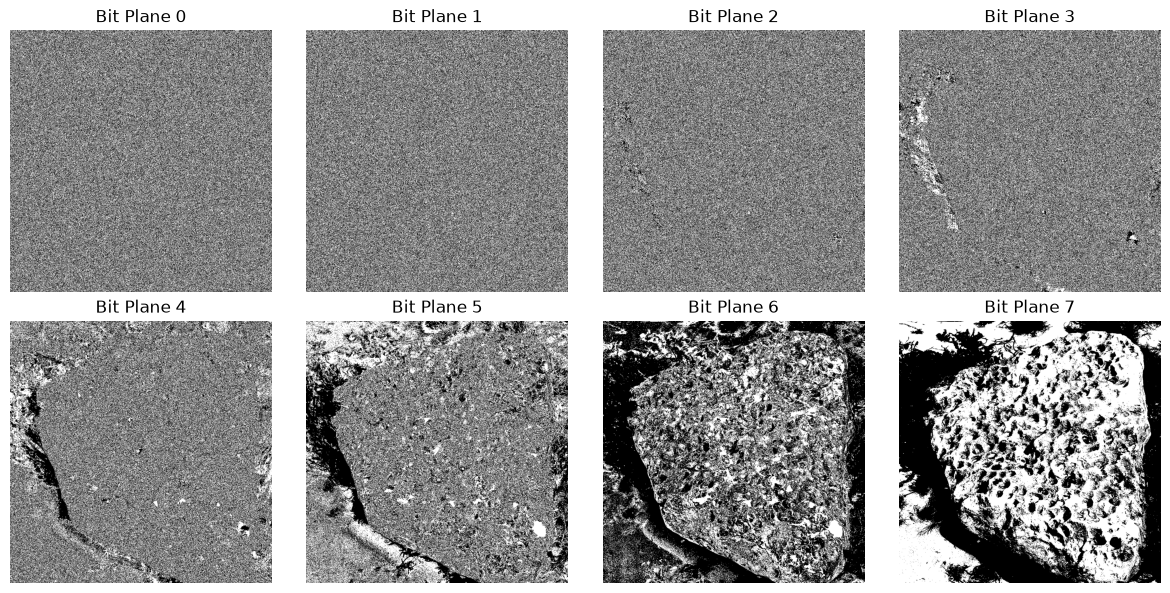

In [4]:
img = np.asarray(Image.open("../../images/p2/cover_textured.png")).astype(np.uint8)

planes = bit_planes(img)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(8):
    axes.flat[i].imshow(planes[i], cmap="gray", vmin=0, vmax=1)
    axes.flat[i].set_title(f"Bit Plane {i}")
    axes.flat[i].axis("off")

plt.tight_layout()
plt.show()

In [5]:
def reconstruct(planes, keep):
    planes = np.asarray(planes, dtype=np.uint8)

    if not 0 <= keep <= 8:
        raise ValueError("keep must be between 0 and 8")

    result = np.zeros(planes.shape[1:], dtype=np.uint8)

    for b in range(8 - keep, 8):
        result |= planes[b] << b

    return result

In [6]:
reconstructed = reconstruct(planes, 8)

print("Same image:", np.array_equal(img, reconstructed))
print("Max difference:", np.max(np.abs(
    img.astype(np.int16) - reconstructed.astype(np.int16)
)))
print("PSNR:", psnr(img, reconstructed))

Same image: True
Max difference: 0
PSNR: inf


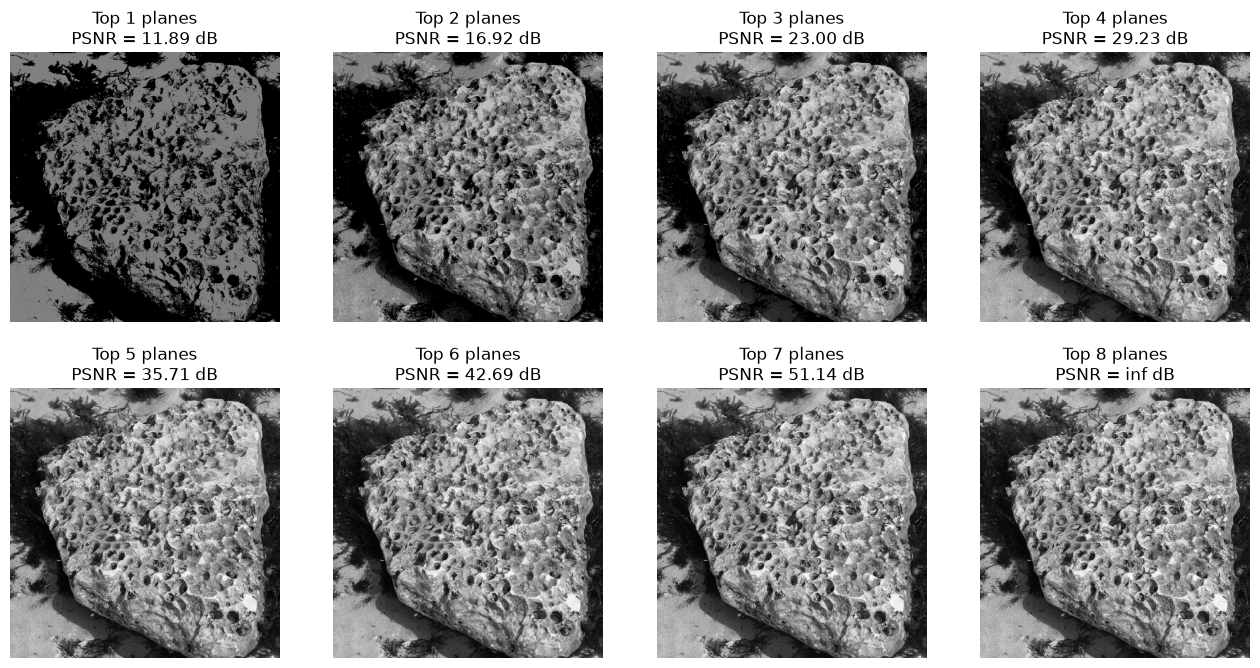

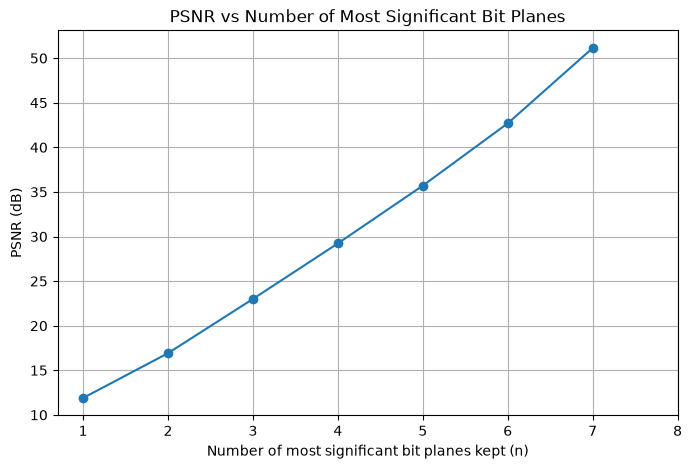

In [7]:
psnr_values = []
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for n in range(1, 9):
    reconstructed = reconstruct(planes, n)
    curr_psnr = psnr(img, reconstructed)
    
    psnr_values.append(curr_psnr)
    axes.flat[n - 1].imshow(reconstructed, cmap="gray", vmin=0, vmax=255)
    axes.flat[n - 1].set_title(f"Top {n} planes\nPSNR = {curr_psnr:.2f} dB")
    axes.flat[n - 1].axis("off")
plt.show()
plt.figure(figsize=(8, 5))

plt.plot(range(1, 9), psnr_values, marker="o")
plt.xlabel("Number of most significant bit planes kept (n)")
plt.ylabel("PSNR (dB)")
plt.title("PSNR vs Number of Most Significant Bit Planes")
plt.xticks(range(1, 9))
plt.grid(True)
plt.show()

## Observation
### Values
n=1: 11.89 dB

n=2 16.92 dB

n=3 23.00 dB

n=4 29.23 dB

n=5 35.71 dB

n=6 42.69 dB

n=7 51.14 dB

n=8 inf
### Difference
16.92-11.89 = 5.03

23.00 - 16.92 = 6.08

29.23 - 23.00 = 6.23

35.71 - 29.23 = 6.48

42.69 - 35.71 = 6.98

51.14 − 42.46 = 8.45

## Approximately constant
the increase in PSNR is approximately constant, this is due to the quantization introduced by discarding the lower order bits. Adding a bit makes the del = 2^(8-n) halfed. This causes the MSE to be quartered, this causes a change in PSNR =

del PSNR = 10log(4) = 6dB.

The values dont exactly match this as this calculation assumes the quantization variable to behave like a uniform random varriable which is not necessarily true. The lower n suggests discarding many bits at once so the residual are much more closer to the uniform random variable assumption which is why the values are closer to 6 for them. 


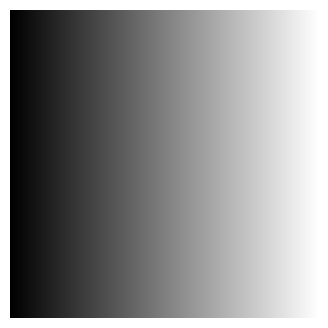

In [8]:
H, W = img.shape
ramp = np.tile( np.linspace(0, 255, W, dtype=np.uint8), (H, 1))

plt.figure(figsize=(10, 4))
plt.imshow(ramp, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.show()

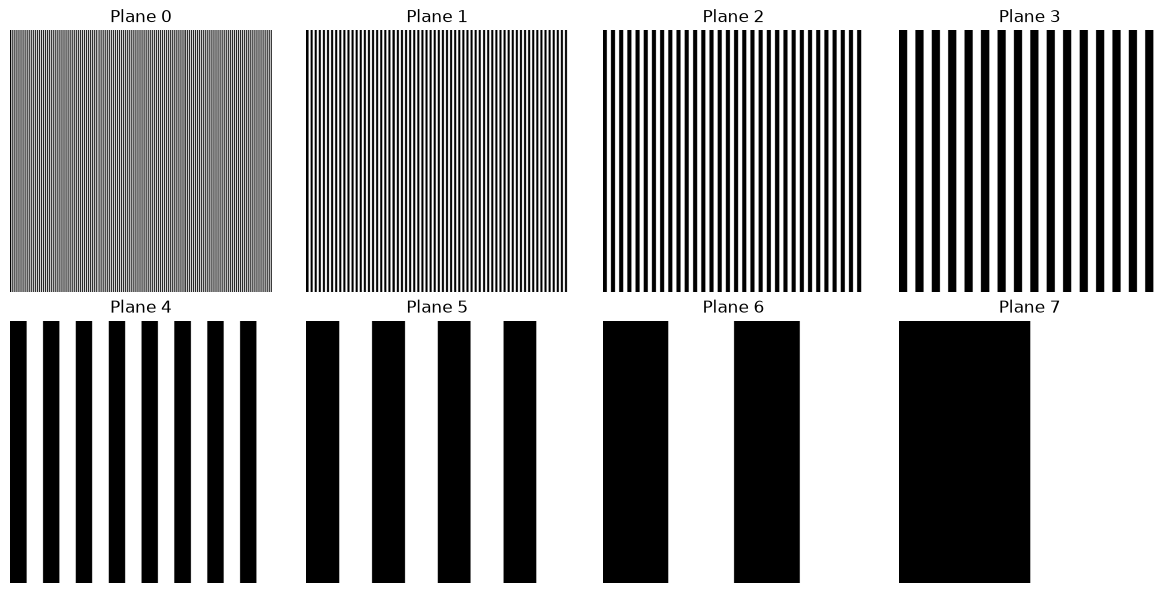

In [9]:
ramp_planes = bit_planes(ramp)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i in range(8):
    axes.flat[i].imshow(ramp_planes[i],cmap="gray",vmin=0,vmax=1)
    axes.flat[i].set_title(f"Plane {i}")
    axes.flat[i].axis("off")

plt.tight_layout()
plt.show()

### Difference between lower order planes
In case of the ramp, we increase the value gradually from 0 to 255. In binary this means we increase the binary by 1 every time. This refers to fixed patterns like the LSB alternating, the next bit alternating every 2 increments (0 0 1 1..) the next every 4 bits and so on. 

Hence upong visualization low planes contain periodic binary patterns caused by the binary counting sequence.

In [10]:
def gray_encode(img):
    img = np.asarray(img, dtype=np.uint8)
    return img ^ (img >> 1)

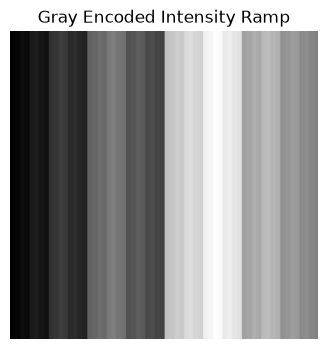

In [11]:
gray_ramp = gray_encode(ramp)

plt.figure(figsize=(10, 4))
plt.imshow(gray_ramp, cmap="gray", vmin=0, vmax=255)
plt.title("Gray Encoded Intensity Ramp")
plt.axis("off")
plt.show()

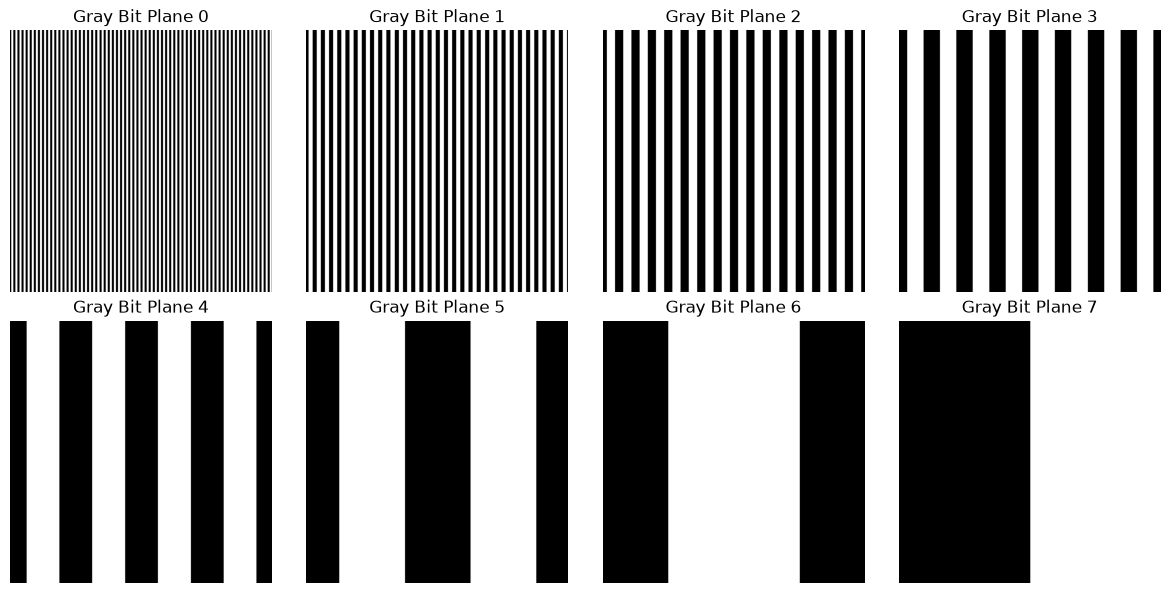

In [12]:
gray_planes = bit_planes(gray_ramp)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(8):
    axes.flat[i].imshow(gray_planes[i],cmap="gray",vmin=0,vmax=1)
    axes.flat[i].set_title(f"Gray Bit Plane {i}")
    axes.flat[i].axis("off")

plt.tight_layout()
plt.show()

The gray encode is such that the adjascent integer values differ by a single bit in the binary representation. The bit plane structure hence recieved is different around intensity transitions.Visually we notice that the dramatic simultaneous bit transitions present in the ordinary binary representations are greatly reduced in the Gray-coded representation.

In [13]:
def embed_lsb(cover, bits, plane=0):
    cover = np.asarray(cover, dtype=np.uint8)
    bits = np.asarray(bits, dtype=np.uint8)
    stego = cover.copy().flatten()
    mask = np.uint8(1 << plane)
    stego[:len(bits)] = (stego[:len(bits)] & ~mask) | (bits << plane)
    return stego.reshape(cover.shape)

In [14]:
def extract_lsb(stego, n, plane=0):
    stego = np.asarray(stego, dtype=np.uint8)
    flat = stego.flatten()
    return ((flat[:n] >> plane) & 1).astype(np.uint8)

Sync marker: 10101010
Payload dimensions: 64 x 64


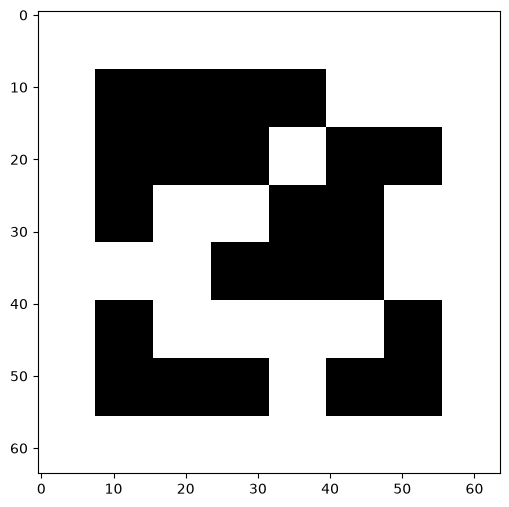

In [15]:
stego_img = np.asarray(Image.open("../../images/p2/decode_me.png")).astype(np.uint8)
H_s, W_s = stego_img.shape
all_bits = extract_lsb(stego_img, H_s * W_s, plane=0)

sync = all_bits[0:8]
print(f"Sync marker: {''.join(map(str, sync))}")

height = int(''.join(map(str, all_bits[8:16])), 2)
width  = int(''.join(map(str, all_bits[16:24])), 2)
print(f"Payload dimensions: {height} x {width}")

payload_bits = all_bits[24 : 24 + height * width]
payload = payload_bits.reshape(height, width)

plt.figure(figsize=(6, 6))
plt.imshow(payload, cmap='gray', vmin=0, vmax=1)
plt.show()

Sync marker given in the question is retrieved 10101010

The Payload dimension height is 64 and the payload dimension width is 64.

Finally the payload is extracted and shown

PSNR: 75.2426 dB


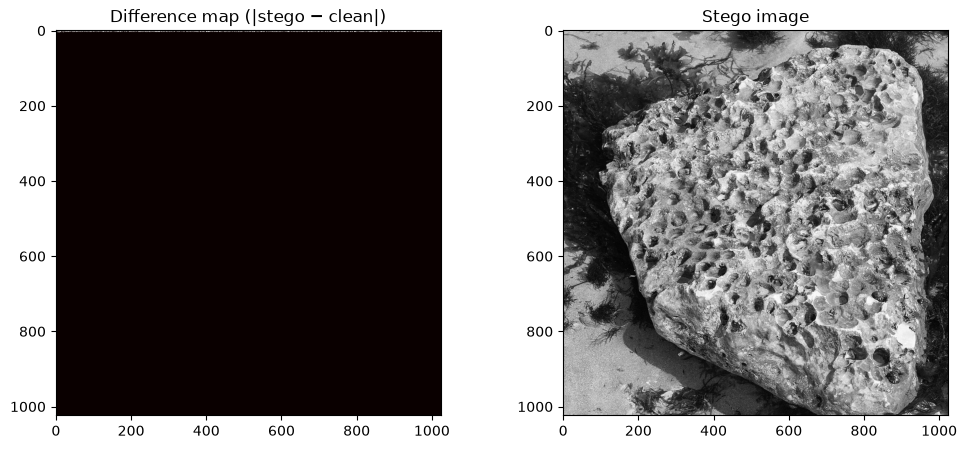

In [16]:
clean_cover = np.asarray(Image.open("../../images/p2/cover_textured.png")).astype(np.uint8)
stego_psnr = psnr(clean_cover, stego_img)
print(f"PSNR: {stego_psnr:.4f} dB")

diff = stego_img.astype(np.int16) - clean_cover.astype(np.int16)
n_changed = np.sum(diff != 0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(np.abs(diff), cmap='hot', vmin=0, vmax=1)
axes[0].set_title("Difference map (|stego − clean|)")
axes[1].imshow(stego_img, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Stego image")

plt.show()

The PSNR is 75.2426 dB

No it was not possible to tell just visually that the image was modified and contains a payload. This is because the payload made changes which led to +-1 difference in the grey level which is not possible to visually percieve

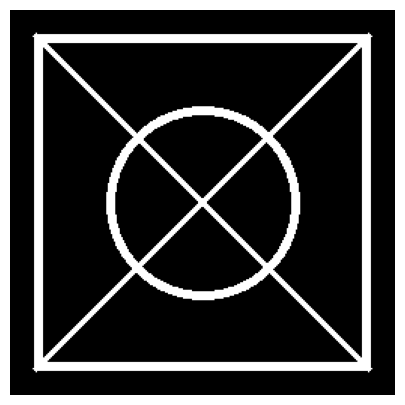

In [17]:
from PIL import Image, ImageDraw, ImageFont
### GENERATED CODE BY CLAUDE
def make_payload(size=256):
    canvas = Image.new("L", (size, size), color=0)
    draw = ImageDraw.Draw(canvas)
    draw.rectangle([16, 16, size-17, size-17], outline=255, width=6)
    draw.ellipse([size//4, size//4, 3*size//4, 3*size//4], outline=255, width=6)
    draw.line([16, 16, size-17, size-17], fill=255, width=4)
    draw.line([16, size-17, size-17, 16], fill=255, width=4)

    arr = (np.asarray(canvas) > 0).astype(np.uint8)
    return arr

payload_256 = make_payload(size=256)

plt.figure(figsize=(5, 5))
plt.imshow(payload_256, cmap='gray', vmin=0, vmax=1)
plt.axis('off')
plt.show()
### END OF GENERATED CODE

PSNR textured: 38.89 dB
PSNR smooth:   39.44 dB


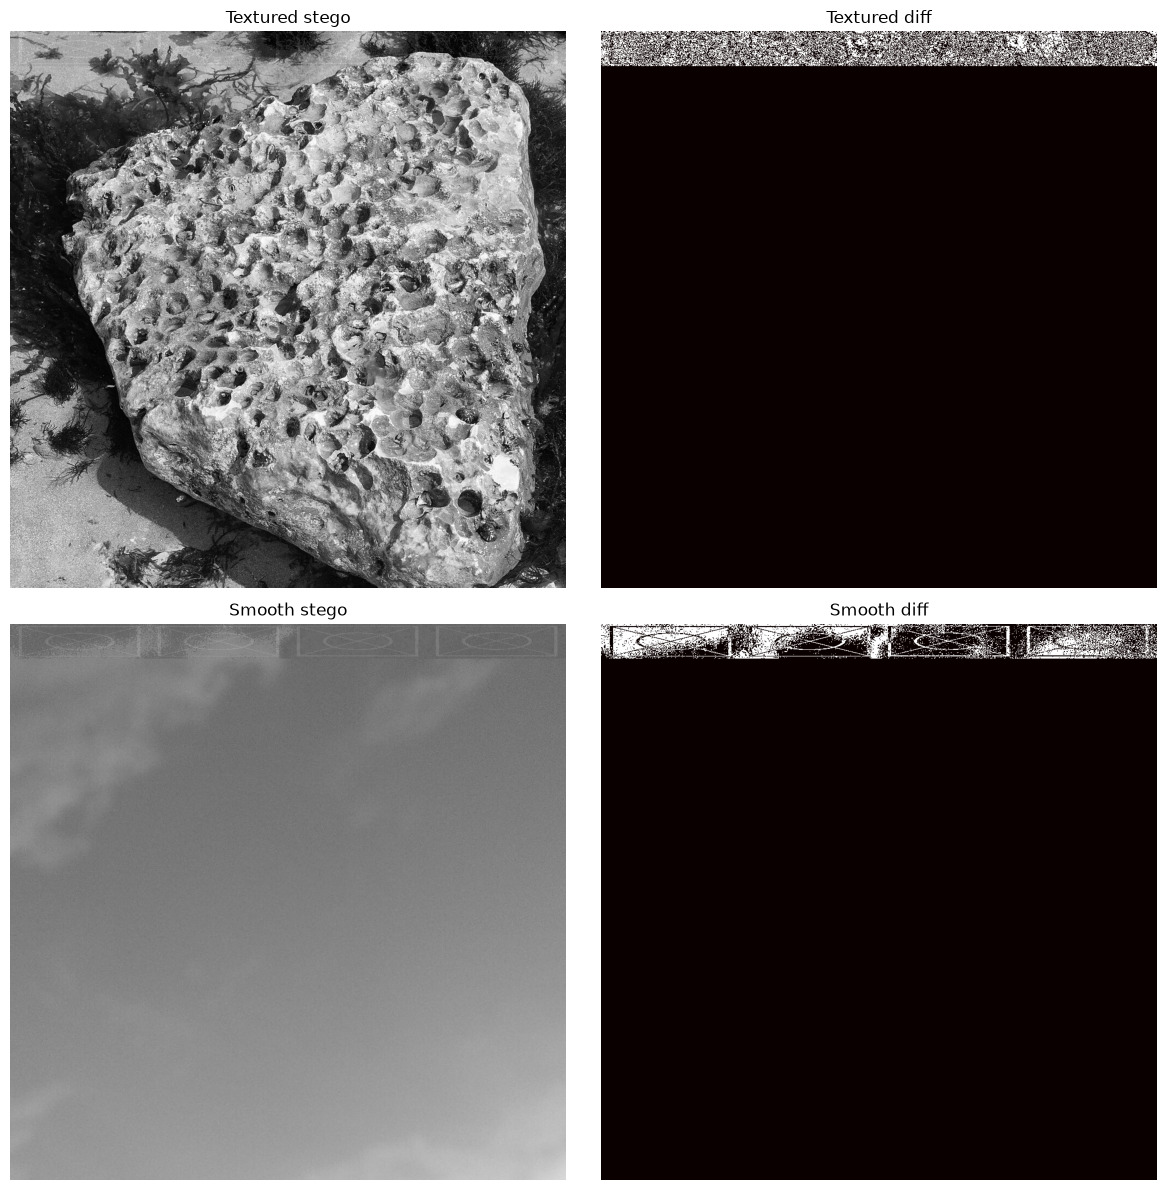

In [18]:
cover_textured = np.asarray(Image.open("../../images/p2/cover_textured.png")).astype(np.uint8)
cover_smooth   = np.asarray(Image.open("../../images/p2/cover_smooth.png")).astype(np.uint8)
full_bits = payload_256.flatten().astype(np.uint8)

stego_textured = embed_lsb(cover_textured, full_bits, plane=4)
stego_smooth   = embed_lsb(cover_smooth,   full_bits, plane=4)

psnr_t = psnr(cover_textured, stego_textured)
psnr_s = psnr(cover_smooth,   stego_smooth)
print(f"PSNR textured: {psnr_t:.2f} dB")
print(f"PSNR smooth:   {psnr_s:.2f} dB")

diff_t = np.abs(stego_textured.astype(np.int16) - cover_textured.astype(np.int16))
diff_s = np.abs(stego_smooth.astype(np.int16)   - cover_smooth.astype(np.int16))

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes[0,0].imshow(stego_textured, cmap='gray', vmin=0, vmax=255)
axes[0,0].set_title("Textured stego")
axes[0,0].axis('off')
axes[0,1].imshow(diff_t, cmap='hot', vmin=0, vmax=1)
axes[0,1].set_title("Textured diff")
axes[0,1].axis('off')
axes[1,0].imshow(stego_smooth, cmap='gray', vmin=0, vmax=255)
axes[1,0].set_title("Smooth stego")
axes[1,0].axis('off')
axes[1,1].imshow(diff_s, cmap='hot', vmin=0, vmax=1)
axes[1,1].set_title("Smooth diff")
axes[1,1].axis('off')
plt.tight_layout()
plt.show()

We used plane 4 for both images. This is to make the structural difference visible in the case of smooth image. Plane-0 which was used earlier for decoding doesnt show varying enough results (When printed the planes which are less significant for smooth it shows random errors similar to the texture. 

As we can see in the top part of the smooth image + payload the texture has changed, This is because in a smooth image pixel values change gradually and has long runs of identical bits. Upon injecting the payload the bits no longer have identical runs of same bits. This however is still hard to detect visually as it brings about changes of order +-1 grey.

In the textured image there are natural rough textures which means the LSB is very random across the whole image, injecting the noise brings close to no change against the surrounding noise.

The PSNR of both smooth and textured image is same as the number of one level changes are same (around 50%). 

The evidence lies in comparing the texture of the before and after pictures and the diff for the top part (where the payload is added) which changes from long stretches of same order bits to changes reflecting the payload throughout

In [19]:
def embed_robust(cover, bits, A=2):
    cover = cover.astype(np.float64)
    H, W = cover.shape
    n = len(bits)
    rows_per_block = H // n
    stego = cover.copy()
    for i, b in enumerate(bits):
        r0, r1 = i*rows_per_block, (i+1)*rows_per_block
        offset = A if b else -A
        stego[r0:r1, :] += offset
    return np.clip(np.round(stego), 0, 255).astype(np.uint8)

In [20]:
def extract_robust(stego, cover, n, A=2):
    stego = stego.astype(np.float64); cover = cover.astype(np.float64)
    H, W = stego.shape
    rows_per_block = H // n
    bits = np.zeros(n, dtype=np.uint8)
    for i in range(n):
        r0, r1 = i*rows_per_block, (i+1)*rows_per_block
        diff_mean = np.mean(stego[r0:r1, :] - cover[r0:r1, :])
        bits[i] = 1 if diff_mean > 0 else 0
    return bits

Here A was chosen as 2 as default as every pixel in the image is modified, so MSE = A² = 4 and PSNR = 10·log10(255²/4) ≈ 42.1 dB which is greater than the 40 dB floor provided in the question

For Gaussian at sigma = 5: as we are averaging 8192 independent noise samples, the standard deviation shrinks by root 8192 which is ~90.5. At sigma = 5. this is 5/90.5 = 0.055 As we are using margin of 2 (2/5/90.5) ~ 36 sigma this makes the probability of error astronomically small (~0)

For JPEG: As the offset is constant this is a pure DC shift which is preserved by JPEG compression.

a) The extractor implemented needs cover. Going without cover would mean the decoder has to estimate each stripe's expected mean without the original.

One way to implement it could be to use differential encoding between adjacent stripe-pairs (encode each bit as the sign of the difference between two stripes). This however would half the bit budget.

(b)40 dB allows MSE ≤ 6.50 total. Since every pixel is modified the per-modified-pixel budget is 6.50 fully. This allows for huge averaging gain as we no longer have one fragile pixel per bit. This is why we get ~0 BER achievable.

In [21]:
sigmas = [0, 1, 2, 5, 10, 20]
n_bits = 128
bits = np.random.default_rng(1).integers(0, 2, n_bits).astype(np.uint8)

stego_robust = embed_robust(cover_textured, bits, A=2)
stego_naive  = embed_lsb(cover_textured, bits)

ber_robust, ber_naive = [], []
for s in sigmas:
    noisy_r = degrade_gaussian(stego_robust, s)
    noisy_n = degrade_gaussian(stego_naive, s)
    ber_robust.append(ber(bits, extract_robust(noisy_r, cover_textured, n_bits, A=2)))
    ber_naive.append(ber(bits, extract_lsb(noisy_n, n_bits)))

jpeg_r = degrade_jpeg(stego_robust, 75)
jpeg_n = degrade_jpeg(stego_naive, 75)
print("robust JPEG BER:", ber(bits, extract_robust(jpeg_r, cover_textured, n_bits, A=2)))
print("naive  JPEG BER:", ber(bits, extract_lsb(jpeg_n, n_bits)))
print("stego PSNR (robust):", psnr(cover_textured, stego_robust))

robust JPEG BER: 0.0
naive  JPEG BER: 0.5546875
stego PSNR (robust): 42.111117048397546


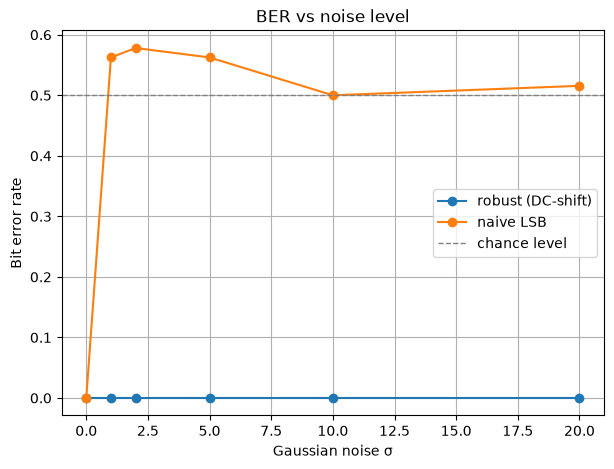

In [22]:
plt.figure(figsize=(7,5))
plt.plot(sigmas, ber_robust, marker='o', label='robust (DC-shift)')
plt.plot(sigmas, ber_naive, marker='o', label='naive LSB')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='chance level')
plt.xlabel('Gaussian noise σ')
plt.ylabel('Bit error rate')
plt.title('BER vs noise level')
plt.legend()
plt.grid(True)
plt.show()

The implemented robust embedding when seen in the mentioned triangle is close to the robustness and imperceptibility corners of the triangle and far from the capacity corner.

The naive embedding sits at the opposite extreme: 1 bit per pixel gives it maximum capacity (over 10⁶ bits available in a 1024×1024 image) but near-zero robustness, since a single-level LSB flip carries no margin against either noise or JPEG compression.

the proposed embedding spreads each of the 128 bits across an 8192-pixel blocks, repeating the same signal 8192 times. Repeating a signal N times and averaging at the decoder shrinks the effective noise standard deviation by √N, so 8192 repeats give a ≈90× noise reduction which is why BER measured exactly 0 across the entire tested range (sigma from 1 up to 20)